In [2]:
HAGRID_DATASET_PATH = "./gesture_dataset_sample/gesture_dataset_sample/"
OWN_DATASET_PATH = "./gesture_dataset/"

In [27]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random, keras

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness, LeakyReLU

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['like', 'stop', 'dislike', 'rock', 'peace']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

## helper function to load and parse annotations

In [4]:
hagrid_annotations = dict()

for condition in CONDITIONS:
    with open(f'{HAGRID_DATASET_PATH}_annotations/{condition}.json') as f:
        hagrid_annotations[condition] = json.load(f)
        
        
hagrid_annotations

{'like': {'0014182f-d756-42b3-896c-c52de76926bb': {'bboxes': [[0.38056273,
     0.35650891,
     0.17322347,
     0.10461114]],
   'labels': ['like'],
   'landmarks': [[[0.5497169170918876, 0.4276043615779976],
     [0.5218336293004483, 0.40536586667786917],
     [0.48288133220125257, 0.3930262243722419],
     [0.4501841862302019, 0.37981099195030416],
     [0.44251365410099686, 0.36620499322043343],
     [0.43138297470865106, 0.406093902776592],
     [0.4072660997339628, 0.4073950234480344],
     [0.42588200316326846, 0.40612291879594015],
     [0.4441470003072778, 0.4049221293588555],
     [0.4314493576491367, 0.4212979654419442],
     [0.42096276272263283, 0.4180224457320293],
     [0.43966095717106257, 0.4163441895714394],
     [0.45584443128098306, 0.41643247458990734],
     [0.4399742832485622, 0.4347478484477659],
     [0.43512361573721164, 0.42874760405890505],
     [0.44966112930536684, 0.42732603739798153],
     [0.46521777606118425, 0.42773384627175054],
     [0.449713075839

In [5]:
own_annotations = dict()


with open(f"{OWN_DATASET_PATH}annot-marcel.json") as f:
    content = json.load(f)
    for condition in CONDITIONS:
        own_annotations[condition] = {}

        for entry in content.items():
            print(entry)
            hagrid_labels = entry[1]["labels"]
            if condition in hagrid_labels:
                own_annotations[condition][entry[0]] = entry[1]
            
own_annotations

('0ce1ffcc-2b29-4131-9962-ef33ec4c69b2', {'bboxes': [[0.44895833333333335, 0.7148148148148148, 0.0359375, 0.09259259259259259]], 'labels': ['dislike']})
('ab448afa-0fe7-4085-a78f-b864be05e256', {'bboxes': [[0.5130208333333334, 0.5453703703703704, 0.0359375, 0.08148148148148149]], 'labels': ['dislike']})
('7b797adc-2c97-4b35-96da-a2513efcae1e', {'bboxes': [[0.4635416666666667, 0.5361111111111111, 0.041666666666666664, 0.11018518518518519]], 'labels': ['dislike']})
('16381d40-abc8-43bd-9558-f215bfbc7939', {'bboxes': [[0.42291666666666666, 0.5314814814814814, 0.06061666666666667, 0.1425925925925926]], 'labels': ['like']})
('67838083-3da4-45c6-afea-82aaa88e8538', {'bboxes': [[0.45625, 0.5481481481481482, 0.07085, 0.17314814814814813]], 'labels': ['like']})
('9e4335da-bdb3-4ae0-9bdc-846eeb5a379d', {'bboxes': [[0.4869791666666667, 0.5694444444444444, 0.0453125, 0.10925925925925926]], 'labels': ['like']})
('8b492eee-c6b2-4bbc-b7f8-b502c069e1d4', {'bboxes': [[0.4015625, 0.6259259259259259, 0.0

{'like': {'16381d40-abc8-43bd-9558-f215bfbc7939': {'bboxes': [[0.42291666666666666,
     0.5314814814814814,
     0.06061666666666667,
     0.1425925925925926]],
   'labels': ['like']},
  '67838083-3da4-45c6-afea-82aaa88e8538': {'bboxes': [[0.45625,
     0.5481481481481482,
     0.07085,
     0.17314814814814813]],
   'labels': ['like']},
  '9e4335da-bdb3-4ae0-9bdc-846eeb5a379d': {'bboxes': [[0.4869791666666667,
     0.5694444444444444,
     0.0453125,
     0.10925925925925926]],
   'labels': ['like']}},
 'stop': {'195730b9-2c63-43cb-b51f-6f14b3a214c0': {'bboxes': [[0.4036458333333333,
     0.5723333333333334,
     0.05625,
     0.15833333333333333]],
   'labels': ['stop']},
  '5d600448-c16a-4a97-b22e-8e2efb449e5f': {'bboxes': [[0.4083333333333333,
     0.5563814814814815,
     0.0453125,
     0.13055555555555556]],
   'labels': ['stop']},
  'd0637059-b092-4a55-964f-feeddc09b1ca': {'bboxes': [[0.4375,
     0.5368370370370371,
     0.03802083333333333,
     0.11388888888888889]],
   'la

In [19]:
# print(json.dumps(hagrid_annotations['like']['00bea9e7-add1-4cc3-b4bc-bcf234966a77'], indent=2))
print(json.dumps(own_annotations['peace']['4f6bba91-d321-4950-924c-eed5ea67acfe'], indent=2))




{
  "bboxes": [
    [
      0.4921875,
      0.2942222222222222,
      0.0609375,
      0.17407407407407408
    ],
    [
      0.23489583333333333,
      0.8805555555555555,
      0.06354166666666666,
      0.11688888888888889
    ]
  ],
  "labels": [
    "peace",
    "no_gesture"
  ]
}


## helper function to pre-process images (color channel conversion and resizing)

In [20]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load hagrid images and annotations

In [21]:
hagrid_images = [] # stores actual image data
hagrid_labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(HAGRID_DATASET_PATH + condition)):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{HAGRID_DATASET_PATH + condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = hagrid_annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label == "no_gesture":
                continue
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            hagrid_images.append(preprocessed)
            hagrid_labels.append(label_index)
            
            

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

In [22]:
own_images = [] 
own_labels = [] 
own_label_names = [] 

for condition in CONDITIONS:
    for filename in tqdm(os.listdir(OWN_DATASET_PATH + condition)):
        
        UID = filename.split('.')[0]
        img = cv2.imread(f'{OWN_DATASET_PATH + condition}/{filename}')

        try:
            annotation = own_annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            label = annotation['labels'][i]
            if label == "no_gesture":
                continue
            if label not in own_label_names:
                own_label_names.append(label)
            
            label_index = label_names.index(label) # use index from prev created list
            
            own_images.append(preprocessed)
            own_labels.append(label_index)



  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

['like', 'stop', 'dislike', 'rock', 'peace']
15
[0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4]


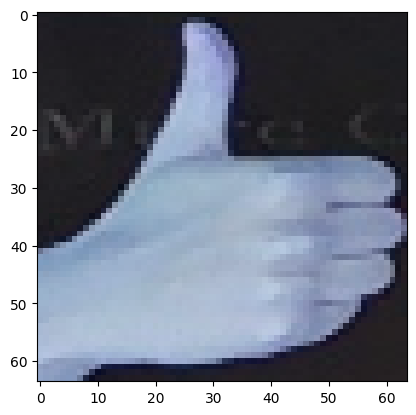

In [23]:
plt.imshow(random.sample(own_images, 1)[0])
print(own_label_names)
print(len(own_images))
print(own_labels)

## do not split data set into train and test!

=> train is the whole (subset of) HaGRID dataset
=> test are the images from me

x is for the actual data, y is for the label (this is convention)

In [24]:
X_train, X_test, y_train, y_test = hagrid_images, own_images, hagrid_labels, own_labels
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

1250
15
1250
15


## transform data sets into a format compatible with our neural network

image data has to be a numpy array with following dimensions: [image_id, y_axis, x_axis, color_channels]

furthermore, scale all values to a range of 0 to 1

training data has to be converted to a categorial vector ("one hot"):

[3] --> [0, 0, 0, 1, 0, ..., 0]

In [25]:
X_train = np.array(X_train).astype('float32')
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.

y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(1250, 64, 64, 3) (15, 64, 64, 3) (1250, 5) (15, 5)


In [28]:
# variables for hyperparameters 
# simply reuse this from given notebook

batch_size = 8
epochs = 50
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'LeakyReLU'  # LeakyReLU
# I got an error with this: ValueError Could not interpret activation function identifier: LeakyReLU
# I changed the Conv2D layers so it works and added the LeakyReLU as extra layers afterwards
layer_count = 2
num_neurons = 64

# define model structure
# with keras, we can use a model's add() function to add layers to the network one by one
model = Sequential()

# data augmentation (this can also be done beforehand - but don't augment the test dataset!)
model.add(RandomFlip('horizontal'))
model.add(RandomContrast(0.1))
#model.add(RandomBrightness(0.1))
#model.add(RandomRotation(0.2))

# first, we add some convolution layers followed by max pooling
model.add(Conv2D(64, kernel_size=(9, 9), input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
model.add(LeakyReLU())

model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

model.add(Conv2D(32, (5, 5), padding='same'))
model.add(LeakyReLU())

model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

model.add(Conv2D(32, (3, 3), padding='same'))
model.add(LeakyReLU())
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

# dropout layers can drop part of the data during each epoch - this prevents overfitting
model.add(Dropout(0.2))

# after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
model.add(Flatten())

# add some fully connected layers ("Dense")
for i in range(layer_count - 1):
    model.add(Dense(num_neurons, activation=activation))

model.add(Dense(num_neurons, activation=activation))

# for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
model.add(Dense(num_classes, activation='softmax'))

# specify loss function, optimizer and evaluation metrics
# for classification, categorial crossentropy is used as a loss function
# use the adam optimizer unless you have a good reason not to
model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

## now, we can train the model using the fit() function
## this will take a while

In [29]:
history = model.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=0,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

In [ ]:
# model.save('gesture_recognition.keras')

# and this is how you load the model
# model = keras.models.load_model("gesture_recognition")

## visualize classification results with a confusion matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
before [[1.0000000e+00 8.3793419e-14 3.8899021e-21 4.0316495e-17 4.4635573e-13]
 [9.9999976e-01 8.5963542e-08 2.0186079e-14 3.1706503e-14 6.1649239e-08]
 [9.9999797e-01 8.0217086e-07 6.1918249e-13 9.5712971e-10 1.1673733e-06]
 [1.7290604e-05 9.9995136e-01 2.4882295e-06 2.6464019e-07 2.8575409e-05]
 [4.0766096e-08 1.0000000e+00 2.0113113e-09 1.0203226e-11 7.4475820e-10]
 [8.0502887e-06 9.9999189e-01 2.4424471e-09 1.3756751e-11 2.3601940e-10]
 [5.6825395e-11 4.4751019e-08 9.9999988e-01 9.8101374e-08 1.3383490e-08]
 [3.3511923e-15 1.8766677e-11 9.9999988e-01 7.6885613e-08 5.9319424e-11]
 [6.9294386e-13 3.6965326e-09 1.0000000e+00 2.4768742e-08 1.2247521e-10]
 [6.6177977e-06 1.3372585e-06 3.1461227e-09 9.9985504e-01 1.3699017e-04]
 [2.6749559e-08 1.0884583e-09 4.0685928e-13 9.9999678e-01 3.1722625e-06]
 [3.7785102e-07 2.3764166e-08 1.5070565e-09 9.9952233e-01 4.7726667e-04]
 [7.9579513e-06 1.6537966e-05 5.3492552e-03 4.2615733e-03 9.9036473e-01]
 [9.43

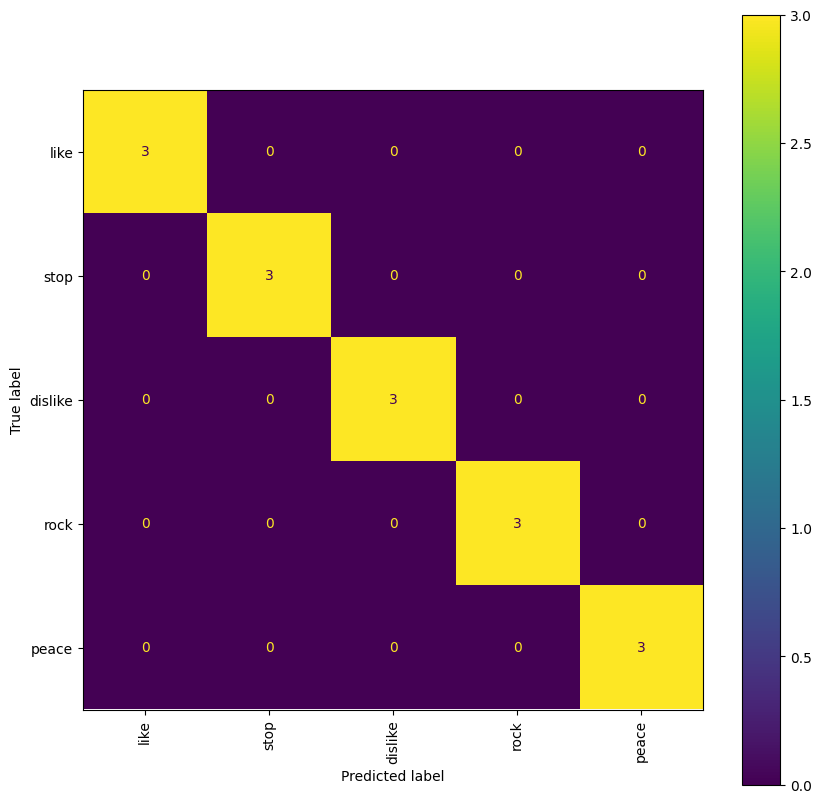

In [32]:
# let the model make predictions for our training data
y_predictions = model.predict(X_test)

# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')

plt.savefig(f"conf-matrix.png", dpi=300, bbox_inches="tight")